# Proyecto Integrador de Inteligencia Artificial
## Segmentación y predicción del riesgo de deserción escolar en el Perú (2021-2024)

**Estudiante:** Luis Enrique Llacua Perez
**Escuela:** Ingeniería Informática — Facultad de Ingeniería Electrónica e Informática
**Universidad:** Universidad Nacional Federico Villarreal
**Curso:** Inteligencia Artificial — Docente: Dr. Ciro Rodríguez Rodríguez
**Periodo académico:** 2026-II

En este cuaderno vamos a desarrollar un proyecto completo de Machine Learning usando datos reales y
abiertos del Ministerio de Educación del Perú (MINEDU) sobre matrícula y trayectoria estudiantil.

El objetivo principal será construir una solución que permita **segmentar** a las instituciones
educativas según su perfil de riesgo académico y, a la vez, **predecir** si una institución
presentará deserción (retiro de estudiantes) en el año siguiente, a partir de sus indicadores del
año actual.


## Objetivos del cuaderno

Al finalizar este cuaderno deberíamos poder:

- Comprender el problema real de la deserción escolar en el Perú y por qué es relevante abordarlo con IA.
- Aplicar un flujo completo de limpieza, integración y preparación de datos reales de gran volumen.
- Construir un modelo de **K-Means** para segmentar instituciones educativas según su perfil académico (aprendizaje no supervisado).
- Construir y comparar modelos de clasificación supervisada (**Regresión Logística** y **KNN**), frente a un modelo base (baseline), para predecir el riesgo de deserción del año siguiente.
- Evaluar los modelos con métricas apropiadas para un problema desbalanceado (precision, recall, F1, ROC-AUC) y con **validación temporal**, para evitar fuga de información (data leakage).
- Justificar la elección final del modelo y explicar cómo ambos modelos (K-Means y Regresión Logística) se complementan dentro de una misma solución.


## Contexto del problema

El dataset que vamos a utilizar proviene del **Padrón de Matrícula y Trayectoria Estudiantil** del
Ministerio de Educación del Perú (MINEDU), correspondiente a los años **2021, 2022, 2023 y 2024**.

Cada fila del archivo original representa una institución educativa (identificada por `cod_mod` y
`anexo`), un nivel educativo (`dsc_nivel`) y un grupo de edad (`Edad`) para un año determinado.
Cada columna describe cuántos estudiantes de ese grupo fueron matriculados, aprobados, desaprobados,
retirados, con atraso escolar, etc.

La deserción escolar (estudiantes que se retiran antes de terminar el año) es un problema educativo
real y documentado en el Perú, con consecuencias en el desarrollo educativo y económico de los
estudiantes afectados. Contar con un modelo capaz de **anticipar** qué instituciones tienen mayor
riesgo de deserción el año siguiente permitiría dirigir mejor las políticas de acompañamiento y
prevención.

> **Nota sobre el dataset:** a diferencia de un dataset de Kaggle, este proviene directamente de una
> fuente oficial de datos abiertos del Estado peruano, y cada fila representa datos reales de
> instituciones educativas reales, no datos sintéticos ni de ejemplo.


## Importación de librerías

Vamos a usar `pandas` y `numpy` para trabajar con los datos, `matplotlib` y `seaborn` para las
visualizaciones, y distintas herramientas de `scikit-learn` para preparar los datos, construir
`Pipeline`s, entrenar los modelos (K-Means, Regresión Logística, KNN) y evaluar los resultados.


In [ ]:
# Importamos librerías para análisis de datos
import os
import json
import numpy as np
import pandas as pd

# Importamos librerías para visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Herramientas de scikit-learn para preparación, pipelines y modelado
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.cluster import KMeans

# Métricas
from sklearn.metrics import (classification_report, confusion_matrix, f1_score,
                              precision_score, recall_score, accuracy_score,
                              roc_curve, roc_auc_score, silhouette_score)

import joblib

sns.set_theme(style="whitegrid")


## Carga del dataset

Los datos vienen en **4 archivos CSV**, uno por año, con el nombre original que entrega el MINEDU:

- `Matriculación y Trayectoria Estudiantil 2021.csv`
- `Matriculación y Trayectoria Estudiantil 2022.csv`
- `Matriculación y Trayectoria Estudiantil 2023.csv`
- `Matriculación y Trayectoria Estudiantil 2024.csv`

Los nombres de archivo (con tilde y guion bajo) deben mantenerse exactamente como los entrega el
MINEDU.


In [11]:
ANIOS = [2021, 2022, 2023, 2024]
NOMBRE_ARCHIVO = "Matriculación y Trayectoria Estudiantil {anio}.csv"

frames = []
for anio in ANIOS:
    ruta_csv = os.path.join(NOMBRE_ARCHIVO.format(anio=anio))
    df_anio = pd.read_csv(ruta_csv)
    df_anio["anio"] = anio
    frames.append(df_anio)
    print(f"Cargado {ruta_csv}: {df_anio.shape[0]:,} filas")

print("\nArchivos cargados correctamente.")


Cargado Matriculación y Trayectoria Estudiantil 2021.csv: 566,359 filas
Cargado Matriculación y Trayectoria Estudiantil 2022.csv: 558,785 filas
Cargado Matriculación y Trayectoria Estudiantil 2023.csv: 544,834 filas
Cargado Matriculación y Trayectoria Estudiantil 2024.csv: 535,137 filas

Archivos cargados correctamente.


### Interpretación de la carga

Cada archivo representa un año distinto (2021 a 2024) y contiene entre 535 mil y 566 mil filas.
En total, antes de cualquier limpieza, disponemos de más de **2.2 millones de registros**, lo cual
cumple ampliamente con el requisito de trabajar con un dataset real y de gran volumen.


## Exploración general del dataset

Antes de limpiar o modelar, revisamos la estructura general: cuántas filas y columnas tiene cada
archivo, qué tipo de dato tiene cada columna y si hay valores faltantes.


In [12]:
# Revisamos la estructura del primer año como referencia
print("Columnas:", frames[0].columns.tolist())
print("\nInformación general (año 2021):")
frames[0].info()


Columnas: ['cod_mod', 'anexo', 'Nombre', 'gestion', 'id_nivel', 'dsc_nivel', 'Edad', 'TipoDiscaIntegrada', 'TotalEstudiantes', 'Discapacidad', 'Mujer', 'Hombre', 'Venezolanos', 'Peruanos', 'Extranjeros', 'DNI_validado', 'DNI_SinValidar', 'No_DNI', 'Aprobado', 'PromocionGuiada', 'Retirado', 'Fallecido', 'RequiereRecuperacion', 'Matriculado', 'PostergaEvaluacion', 'tot_atraso', 'anio']

Información general (año 2021):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 566359 entries, 0 to 566358
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   cod_mod               566359 non-null  int64  
 1   anexo                 566359 non-null  int64  
 2   Nombre                566359 non-null  object 
 3   gestion               566359 non-null  object 
 4   id_nivel              566359 non-null  object 
 5   dsc_nivel             566359 non-null  object 
 6   Edad                  566354 non-null  float64
 

### Interpretación de la exploración general

El dataset combina variables categóricas (`gestion`, `dsc_nivel`, `Nombre`), variables numéricas
(`Edad`, `TotalEstudiantes`, `Retirado`, `tot_atraso`, etc.) y una columna con muchos valores
faltantes (`TipoDiscaIntegrada`), que solo se completa cuando el estudiante tiene una discapacidad
integrada registrada.

También observamos una diferencia importante entre años: los archivos de 2021-2022 incluyen la
columna `PromocionGuiada`, mientras que los de 2023-2024 la reemplazaron por `Desaprobado`. Antes de
unir los 4 años, tenemos que homogenizar estas columnas.


## Homogenización de columnas y unión de los 4 años

Como cada año no tiene exactamente las mismas columnas, agregamos las columnas faltantes con valor
0 antes de concatenar. Esto nos permite trabajar con un único DataFrame para todo el periodo
2021-2024.


In [13]:
for i, df_anio in enumerate(frames):
    if "PromocionGuiada" not in df_anio.columns:
        df_anio["PromocionGuiada"] = 0
    if "Desaprobado" not in df_anio.columns:
        df_anio["Desaprobado"] = 0

df_full = pd.concat(frames, ignore_index=True)
print("Filas totales combinadas (2021-2024):", f"{len(df_full):,}")


Filas totales combinadas (2021-2024): 2,205,115


## Revisión de valores faltantes y duplicados

In [14]:
faltantes = df_full.isnull().sum()
porcentaje_faltantes = (faltantes / len(df_full)) * 100
tabla_faltantes = pd.DataFrame({"valores_faltantes": faltantes, "porcentaje": porcentaje_faltantes})
display(tabla_faltantes[tabla_faltantes["valores_faltantes"] > 0].sort_values("porcentaje", ascending=False))

duplicados = df_full.duplicated().sum()
print("\nFilas duplicadas exactas:", duplicados)


,valores_faltantes,porcentaje
TipoDiscaIntegrada,1940012,87.977815
Edad,6,0.000272



Filas duplicadas exactas: 0


### Interpretación de valores faltantes y duplicados

Las únicas columnas con valores faltantes son `TipoDiscaIntegrada` (la gran mayoría de estudiantes
no tiene una discapacidad integrada registrada, por lo que el valor faltante en realidad significa
"no aplica") y `Edad` (solo 6 filas sobre más de 2.2 millones, un porcentaje insignificante).

No se encontraron filas duplicadas exactas. Con esto, procedemos a limpiar:
- `TipoDiscaIntegrada`: se completa con `"Sin discapacidad integrada"`.
- `Edad`: se eliminan las 6 filas sin valor (menos del 0.001% del dataset).


In [15]:
df_full["TipoDiscaIntegrada"] = df_full["TipoDiscaIntegrada"].fillna("Sin discapacidad integrada")
df_full = df_full.dropna(subset=["Edad"])
df_full["Edad"] = df_full["Edad"].astype(int)
print("Filas después de la limpieza básica:", f"{len(df_full):,}")


Filas después de la limpieza básica: 2,205,109


## Definición de la unidad de análisis

El archivo original tiene una fila por cada combinación de institución + nivel educativo + edad +
año. Para nuestro problema (¿esta institución tendrá deserción?) esa granularidad es demasiado fina:
lo relevante es el comportamiento de la institución en un nivel educativo durante todo el año, no
por cada edad por separado.

Por eso agregamos (sumamos) las columnas numéricas agrupando por institución (`cod_mod`, `anexo`),
`Nombre`, `gestion`, `dsc_nivel` y `anio`. Esta será nuestra unidad de análisis: **institución-nivel-año**.


In [16]:
group_cols = ["cod_mod", "anexo", "Nombre", "gestion", "dsc_nivel", "anio"]
sum_cols = ["TotalEstudiantes", "Discapacidad", "Mujer", "Hombre", "Venezolanos", "Peruanos",
            "Extranjeros", "DNI_validado", "DNI_SinValidar", "No_DNI", "Aprobado",
            "PromocionGuiada", "Desaprobado", "Retirado", "Fallecido", "RequiereRecuperacion",
            "Matriculado", "PostergaEvaluacion", "tot_atraso"]

agg = df_full.groupby(group_cols, as_index=False)[sum_cols].sum()
agg = agg[agg["TotalEstudiantes"] > 0].reset_index(drop=True)
print("Filas tras la agregación (institución-nivel-año):", f"{len(agg):,}")


Filas tras la agregación (institución-nivel-año): 423,012


## Ingeniería de variables: tasas e indicadores proporcionales

Trabajar con conteos absolutos (`Retirado`, `Aprobado`, etc.) no es comparable entre instituciones
de distinto tamaño. Por eso construimos **tasas** dividiendo cada conteo entre el total de
estudiantes de esa institución-nivel-año.


In [17]:
agg["tasa_retiro"] = agg["Retirado"] / agg["TotalEstudiantes"]
agg["tasa_aprobacion"] = agg["Aprobado"] / agg["TotalEstudiantes"]
agg["tasa_desaprobacion"] = agg["Desaprobado"] / agg["TotalEstudiantes"]
agg["tasa_atraso"] = agg["tot_atraso"] / agg["TotalEstudiantes"]
agg["tasa_fallecido"] = agg["Fallecido"] / agg["TotalEstudiantes"]
agg["prop_mujer"] = agg["Mujer"] / agg["TotalEstudiantes"]
agg["prop_extranjero"] = agg["Extranjeros"] / agg["TotalEstudiantes"]
agg["prop_venezolano"] = agg["Venezolanos"] / agg["TotalEstudiantes"]
agg["prop_discapacidad"] = agg["Discapacidad"] / agg["TotalEstudiantes"]
agg["prop_dni_no_validado"] = (agg["DNI_SinValidar"] + agg["No_DNI"]) / agg["TotalEstudiantes"]
agg["prop_requiere_recuperacion"] = agg["RequiereRecuperacion"] / agg["TotalEstudiantes"]

agg[["tasa_retiro","tasa_atraso","prop_extranjero"]].describe()


,tasa_retiro,tasa_atraso,prop_extranjero
count,423012.000000,423012.000000,423012.000000
mean,0.004658,0.023950,0.004525
std,0.028284,0.066348,0.020640
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,0.000000,0.010526,0.000000
max,1.000000,1.000000,1.000000


## Construcción de la variable objetivo: un panel temporal (año *t* → año *t+1*)

Para este proyecto: **no vamos a predecir la deserción del mismo año con datos del
mismo año**, porque eso sería una fuga de información (*data leakage*) — en la práctica, si queremos
anticiparnos a la deserción, solo tenemos disponibles los datos del año **anterior**.

Por eso construimos un **panel**: para cada institución-nivel, tomamos sus indicadores del año base
`t` (por ejemplo 2021) como variables predictoras, y su `tasa_retiro` del año `t+1` (2022) como base
para la variable objetivo. Repetimos esto para los pares (2021→2022), (2022→2023) y (2023→2024).

La variable objetivo `riesgo_alto_desercion` vale `1` si la institución tuvo **al menos un
estudiante retirado** en el año siguiente, y `0` en caso contrario.


In [18]:
agg["clave"] = agg["cod_mod"].astype(str) + "_" + agg["anexo"].astype(str) + "_" + agg["dsc_nivel"]

feature_cols = ["TotalEstudiantes","tasa_aprobacion","tasa_desaprobacion","tasa_atraso",
                "tasa_fallecido","prop_mujer","prop_extranjero","prop_venezolano",
                "prop_discapacidad","prop_dni_no_validado","prop_requiere_recuperacion"]

pares = []
for anio_t in [2021, 2022, 2023]:
    anio_t1 = anio_t + 1
    dt = agg[agg["anio"] == anio_t].copy()
    dt1 = agg[agg["anio"] == anio_t1][["clave","tasa_retiro"]].rename(
        columns={"tasa_retiro": "tasa_retiro_siguiente"})
    merged = dt.merge(dt1, on="clave", how="inner")
    merged["anio_base"] = anio_t
    pares.append(merged)

panel = pd.concat(pares, ignore_index=True)
panel["riesgo_alto_desercion"] = (panel["tasa_retiro_siguiente"] > 0).astype(int)

cols_finales = ["clave","cod_mod","anexo","Nombre","gestion","dsc_nivel","anio_base"] + \
               feature_cols + ["tasa_retiro","tasa_retiro_siguiente","riesgo_alto_desercion"]
panel = panel[cols_finales]

print("Filas del panel institución-nivel-año (con año siguiente disponible):", f"{len(panel):,}")
panel["riesgo_alto_desercion"].value_counts(normalize=True)


Filas del panel institución-nivel-año (con año siguiente disponible): 311,454


,proportion
riesgo_alto_desercion,
0,0.895692
1,0.104308


### Interpretación de la variable objetivo

El panel final queda con **311,454 registros** (institución-nivel-año con año siguiente
disponible). La variable objetivo está desbalanceada: aproximadamente **89.6%** de los casos no
tuvieron deserción al año siguiente, y **10.4%** sí la tuvieron.

Este desbalance es esperable en un problema de deserción escolar real: la mayoría de las
instituciones-nivel no presentan retiros en un año dado. Por eso, más adelante, no evaluaremos los
modelos solo con *accuracy* (que sería engañoso), sino también con *precision*, *recall*, *F1* y
*ROC-AUC*.


## Visualización de la variable objetivo

/tmp/ipykernel_2412/677695822.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=panel, x="riesgo_alto_desercion", palette=["#4C72B0","#C44E52"])


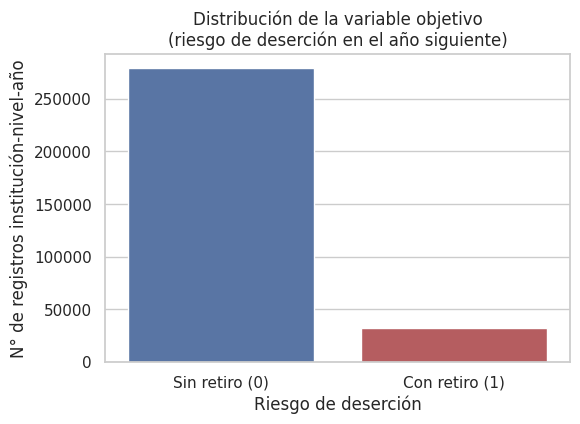

In [19]:
plt.figure(figsize=(6,4))
sns.countplot(data=panel, x="riesgo_alto_desercion", palette=["#4C72B0","#C44E52"])
plt.title("Distribución de la variable objetivo\n(riesgo de deserción en el año siguiente)")
plt.xlabel("Riesgo de deserción")
plt.ylabel("N° de registros institución-nivel-año")
plt.xticks(ticks=[0,1], labels=["Sin retiro (0)","Con retiro (1)"])
plt.show()


## Análisis exploratorio de variables predictoras

Antes de modelar, exploramos cómo se relacionan algunas variables con el riesgo de deserción.


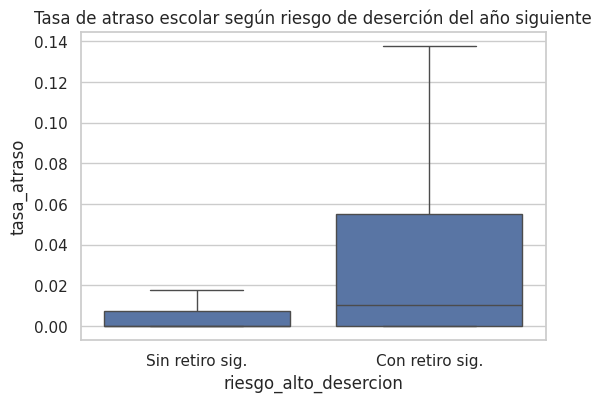

In [20]:
plt.figure(figsize=(6,4))
sns.boxplot(data=panel, x="riesgo_alto_desercion", y="tasa_atraso", showfliers=False)
plt.xticks(ticks=[0,1], labels=["Sin retiro sig.","Con retiro sig."])
plt.title("Tasa de atraso escolar según riesgo de deserción del año siguiente")
plt.show()


### Interpretación

Las instituciones-nivel que sí tienen deserción al año siguiente muestran, en promedio, una tasa de
atraso escolar (estudiantes con atraso respecto a la edad normativa) más alta en el año base. Esto es
consistente con la literatura educativa: el atraso escolar suele ser un indicador temprano de
desvinculación del sistema.


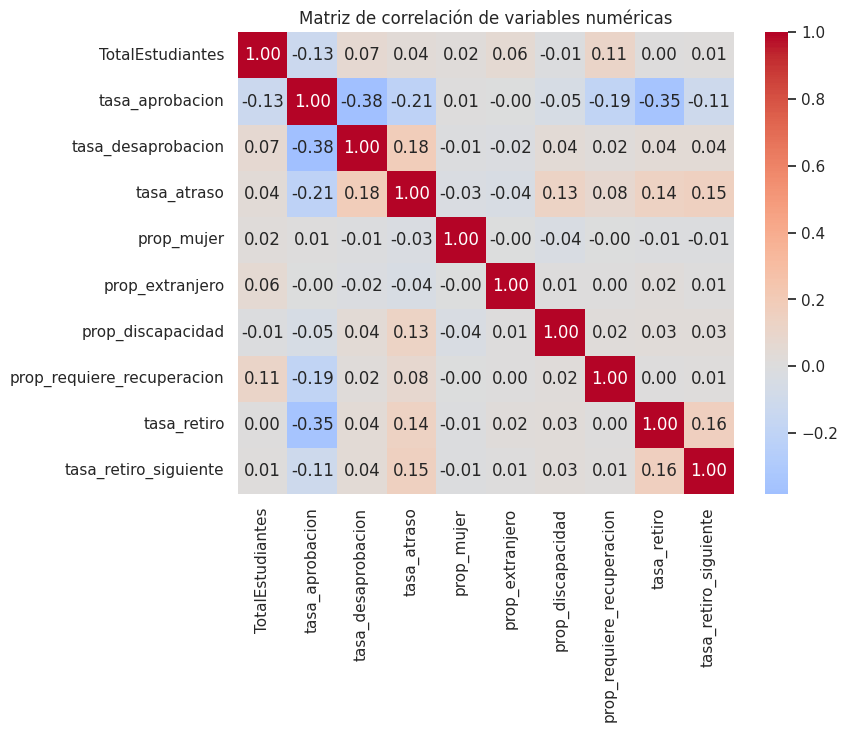

In [21]:
num_cols = ["TotalEstudiantes","tasa_aprobacion","tasa_desaprobacion","tasa_atraso",
            "prop_mujer","prop_extranjero","prop_discapacidad","prop_requiere_recuperacion",
            "tasa_retiro","tasa_retiro_siguiente"]
plt.figure(figsize=(8,6))
sns.heatmap(panel[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlación de variables numéricas")
plt.show()


### Interpretación de la matriz de correlación

La `tasa_retiro` del año base y la `tasa_atraso` son las variables con mayor correlación positiva
con la deserción del año siguiente (0.16 y 0.15 respectivamente), mientras que la `tasa_aprobacion`
tiene una correlación negativa (-0.11): a mayor aprobación en el año base, menor riesgo de deserción
al año siguiente. Ninguna correlación es extremadamente alta, lo que indica que ninguna variable por
sí sola explica la deserción — se necesita un modelo que combine varias señales.


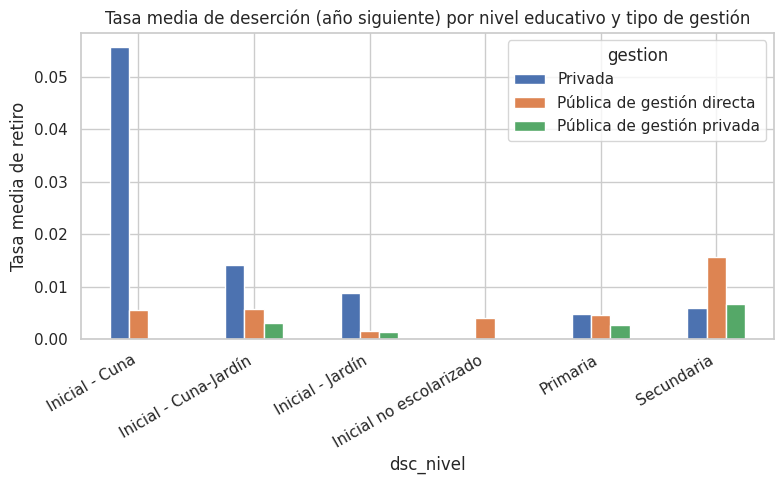

In [22]:
tasa_por_nivel_gestion = panel.groupby(["dsc_nivel","gestion"])["tasa_retiro_siguiente"].mean().unstack()
tasa_por_nivel_gestion.plot(kind="bar", figsize=(8,5))
plt.title("Tasa media de deserción (año siguiente) por nivel educativo y tipo de gestión")
plt.ylabel("Tasa media de retiro")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


### Interpretación

Secundaria presenta una tasa media de deserción notablemente más alta que Primaria e Inicial, lo
cual es consistente con la literatura: la deserción escolar en el Perú tiende a concentrarse en la
etapa secundaria. Esto será un indicador importante para el modelo.


# Preparación de los datos para el modelo

Ya exploramos el panel de datos y entendimos la variable objetivo. Ahora preparamos todo para
entrenar los dos modelos del proyecto:

1. **K-Means** (no supervisado) — segmentación de instituciones por perfil académico.
2. **Regresión Logística**, comparada contra **KNN** y un **baseline** (no supervisado vs. supervisado) — predicción del riesgo de deserción del año siguiente.


In [23]:
num_feats = ["TotalEstudiantes","tasa_aprobacion","tasa_desaprobacion","tasa_atraso",
             "tasa_fallecido","prop_mujer","prop_extranjero","prop_venezolano",
             "prop_discapacidad","prop_dni_no_validado","prop_requiere_recuperacion"]
cat_feats = ["dsc_nivel","gestion"]

X = panel[num_feats + cat_feats]
y = panel["riesgo_alto_desercion"]

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)


Dimensiones de X: (311454, 13)
Dimensiones de y: (311454,)


## División temporal en entrenamiento y prueba

Usamos una **división temporal**:
- **Entrenamiento:** pares con año base 2021 y 2022 (predicen 2022 y 2023).
- **Prueba:** pares con año base 2023 (predice 2024, el año más reciente y nunca visto en entrenamiento).

In [24]:
train_mask = panel["anio_base"].isin([2021, 2022])
test_mask = panel["anio_base"] == 2023

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]

print("Entrenamiento:", X_train.shape, "- proporción positiva:", y_train.mean().round(4))
print("Prueba:       ", X_test.shape,  "- proporción positiva:", y_test.mean().round(4))


Entrenamiento: (207653, 13) - proporción positiva: 0.1039
Prueba:        (103801, 13) - proporción positiva: 0.1051


## Pipeline de preprocesamiento

Construimos un `ColumnTransformer` que:
- estandariza (`StandardScaler`) las variables numéricas;
- codifica (`OneHotEncoder`) las variables categóricas (`dsc_nivel`, `gestion`).

Este preprocesador se reutilizará dentro de cada `Pipeline` de modelo.


In [25]:
preprocesador = ColumnTransformer([
    ("num", StandardScaler(), num_feats),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_feats)
])


---
# Modelo 1: K-Means — segmentación de instituciones educativas

Antes de predecir, buscamos **entender la estructura** de las instituciones educativas: ¿existen
grupos naturales de instituciones con perfiles académicos distintos? Para esto usamos **K-Means**.

A diferencia del modelo supervisado, K-Means **no usa la variable objetivo**: solo usa indicadores
académicos del año base para agrupar instituciones-nivel-año según su comportamiento.


In [26]:
variables_cluster = ["tasa_aprobacion","tasa_desaprobacion","tasa_atraso","prop_discapacidad",
                     "prop_extranjero","prop_requiere_recuperacion","tasa_retiro"]

escalador_cluster = StandardScaler()
X_cluster = escalador_cluster.fit_transform(panel[variables_cluster])


## Elección de *k* con el método de Silhouette

Igual que discutimos en el cuaderno 09a, no sabemos de antemano cuántos grupos (*k*) existen.
Probamos varios valores de *k* y usamos el **silhouette score** para elegir el que produce grupos
mejor separados.


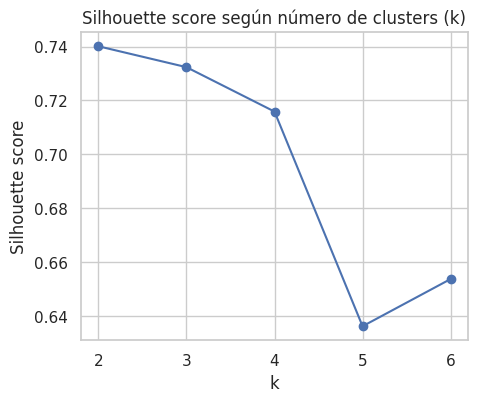

{2: np.float64(0.7401071487101573), 3: np.float64(0.7323533593674163), 4: np.float64(0.7158745777622446), 5: np.float64(0.6362565805986579), 6: np.float64(0.6537737080800042)}


In [27]:
silhouette_por_k = {}
for k in [2, 3, 4, 5, 6]:
    kmeans_k = KMeans(n_clusters=k, random_state=42, n_init=10)
    etiquetas_k = kmeans_k.fit_predict(X_cluster)
    silhouette_por_k[k] = silhouette_score(X_cluster, etiquetas_k, sample_size=20000, random_state=42)

pd.Series(silhouette_por_k).plot(marker="o", figsize=(5,4))
plt.title("Silhouette score según número de clusters (k)")
plt.xlabel("k"); plt.ylabel("Silhouette score")
plt.show()

print(silhouette_por_k)


### Interpretación del silhouette

El mejor valor según silhouette es **k=2** (score ≈ 0.74), notablemente más alto que con k≥3. Esto
sugiere que, en términos de perfil académico, las instituciones se dividen naturalmente en dos
grandes grupos, más que en varios subgrupos. Usamos k=2 para el modelo final.


In [28]:
k_final = 2
kmeans_final = KMeans(n_clusters=k_final, random_state=42, n_init=10)
panel["cluster"] = kmeans_final.fit_predict(X_cluster)

perfil_clusters = panel.groupby("cluster")[variables_cluster].mean()
perfil_clusters["n_registros"] = panel["cluster"].value_counts()
display(perfil_clusters.round(4))


,tasa_aprobacion,tasa_desaprobacion,tasa_atraso,prop_discapacidad,prop_extranjero,prop_requiere_recuperacion,tasa_retiro,n_registros
cluster,,,,,,,,
0,0.9893,0.0016,0.0190,0.0092,0.0045,0.0002,0.0019,291305
1,0.7659,0.0681,0.1236,0.0218,0.0033,0.0067,0.0420,20149


### Interpretación de los clusters

- **Cluster 0** (mayoría, ~291,000 registros): perfil de **bajo riesgo**. Tasa de aprobación
  cercana al 99%, tasas de desaprobación, atraso y retiro muy bajas.
- **Cluster 1** (minoría, ~20,000 registros): perfil **estructuralmente vulnerable**. Tasa de
  aprobación de ~76.6%, con tasas de desaprobación, atraso y retiro notablemente más altas
  (retiro ≈ 4.2% frente a ≈ 0.2% del cluster 0).

Esta segmentación es útil como **diagnóstico**: permite identificar, sin usar ninguna etiqueta de
deserción futura, qué instituciones ya muestran hoy un perfil académico de riesgo.


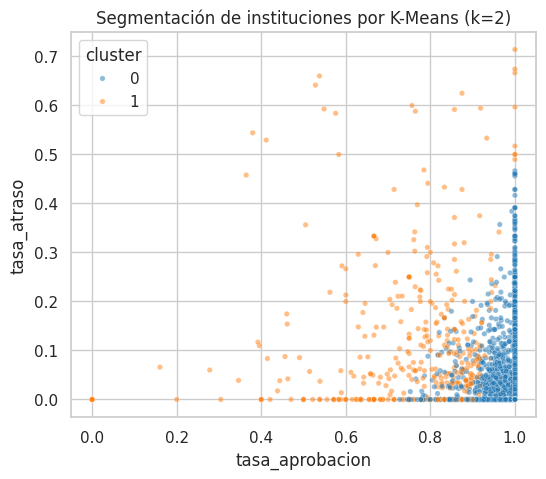

In [29]:
muestra_grafico = panel.sample(6000, random_state=1)
plt.figure(figsize=(6,5))
sns.scatterplot(data=muestra_grafico, x="tasa_aprobacion", y="tasa_atraso",
                hue="cluster", palette="tab10", alpha=0.5, s=15)
plt.title(f"Segmentación de instituciones por K-Means (k={k_final})")
plt.show()


---
# Modelo 2: predicción supervisada del riesgo de deserción

Ahora sí construimos un modelo **supervisado**, que use la variable objetivo `riesgo_alto_desercion`
para predecir si una institución tendrá deserción el año siguiente.

Siguiendo el enfoque del cuaderno 11 (comparación y evaluación de modelos), no elegimos un algoritmo
"porque sí": entrenamos varias alternativas y las comparamos con las mismas métricas sobre el mismo
conjunto de prueba.

Comparamos tres opciones:
1. **Baseline** (`DummyClassifier`): siempre predice la clase mayoritaria. Sirve como piso mínimo de comparación.
2. **Regresión Logística** (cuaderno 06).
3. **KNN** (cuaderno 07), con `k=15`.


In [30]:
modelos = {
    "Baseline (clase mayoritaria)": DummyClassifier(strategy="most_frequent"),
    "Regresión Logística": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "KNN (k=15)": KNeighborsClassifier(n_neighbors=15)
}

pipelines = {}
resultados = []

for nombre, clf in modelos.items():
    pipe = Pipeline([("pre", preprocesador), ("clf", clf)])
    pipe.fit(X_train, y_train)
    pipelines[nombre] = pipe

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1] if hasattr(pipe, "predict_proba") else y_pred

    resultados.append({
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_proba) if len(set(y_proba)) > 2 else np.nan
    })

resultados_df = pd.DataFrame(resultados)
display(resultados_df.round(3))


,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Baseline (clase mayoritaria),0.895,0.000,0.000,0.000,NaN
1,Regresión Logística,0.738,0.253,0.765,0.380,0.812
2,KNN (k=15),0.893,0.465,0.107,0.175,0.790


### Interpretación de la primera comparación

El baseline confirma por qué **no basta con mirar el accuracy** en un problema desbalanceado: logra
~89% de accuracy simplemente prediciendo siempre "sin riesgo", pero su precision, recall y F1 son 0 —
nunca detecta ningún caso de deserción.

La **Regresión Logística** tiene menor accuracy (0.74) que KNN (0.89), pero un **F1 y un recall muy
superiores** (F1=0.38 vs 0.17; recall=0.77 vs 0.11). Es decir: KNN es "conservador" y casi nunca
predice riesgo, mientras que la Regresión Logística detecta muchos más casos reales de deserción, a
costa de más falsas alarmas. En un problema donde interesa **no dejar pasar** instituciones en
riesgo, esto la hace preferible.


## Validación cruzada (cross-validation)

In [31]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_logistica = cross_val_score(pipelines["Regresión Logística"], X_train, y_train, cv=skf, scoring="f1")
cv_knn = cross_val_score(pipelines["KNN (k=15)"], X_train, y_train, cv=skf, scoring="f1")

print("CV F1 Regresión Logística: media =", cv_logistica.mean().round(4), "- desvío =", cv_logistica.std().round(4))
print("CV F1 KNN:                 media =", cv_knn.mean().round(4), "- desvío =", cv_knn.std().round(4))


CV F1 Regresión Logística: media = 0.358 - desvío = 0.0017
CV F1 KNN:                 media = 0.1098 - desvío = 0.0026


### Interpretación de la validación cruzada

La validación cruzada (dentro del conjunto de entrenamiento, 5 particiones) confirma el resultado
anterior de forma más robusta: la Regresión Logística obtiene un F1 promedio de **≈0.358** frente a
**≈0.110** de KNN, con desvíos estándar muy pequeños en ambos casos (por lo tanto, la diferencia es
estable y no producto del azar de una sola partición).


## Curva ROC y AUC

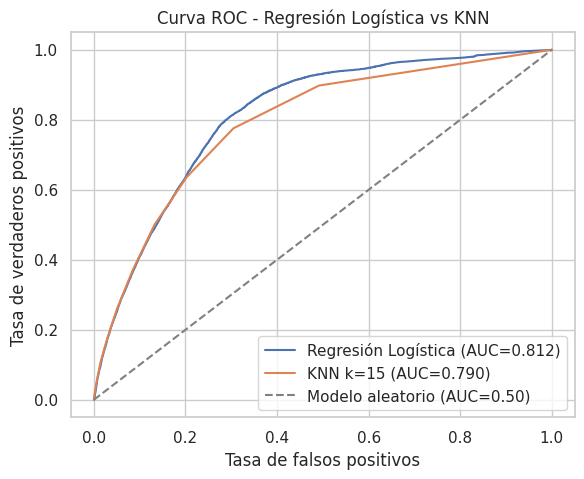

In [32]:
y_prob_logistica = pipelines["Regresión Logística"].predict_proba(X_test)[:, 1]
y_prob_knn = pipelines["KNN (k=15)"].predict_proba(X_test)[:, 1]

fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_logistica)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
auc_log = roc_auc_score(y_test, y_prob_logistica)
auc_knn = roc_auc_score(y_test, y_prob_knn)

plt.figure(figsize=(6.5,5))
plt.plot(fpr_log, tpr_log, label=f"Regresión Logística (AUC={auc_log:.3f})")
plt.plot(fpr_knn, tpr_knn, label=f"KNN k=15 (AUC={auc_knn:.3f})")
plt.plot([0,1],[0,1],"--", color="gray", label="Modelo aleatorio (AUC=0.50)")
plt.xlabel("Tasa de falsos positivos"); plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curva ROC - Regresión Logística vs KNN")
plt.legend()
plt.show()


### Interpretación de la curva ROC

Ambos modelos superan ampliamente al azar (AUC=0.50). La Regresión Logística obtiene un AUC de
**≈0.812**, ligeramente superior al de KNN (**≈0.790**), lo que confirma que, en términos generales,
separa mejor ambas clases a lo largo de distintos umbrales de decisión — no solo en el umbral por
defecto que vimos en la tabla de métricas.


## Matriz de confusión del modelo seleccionado

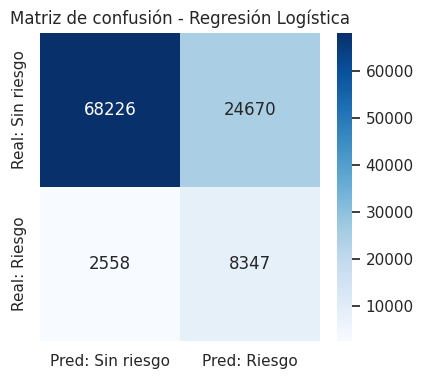

              precision    recall  f1-score   support

           0       0.96      0.73      0.83     92896
           1       0.25      0.77      0.38     10905

    accuracy                           0.74    103801
   macro avg       0.61      0.75      0.61    103801
weighted avg       0.89      0.74      0.79    103801



In [33]:
y_pred_logistica = pipelines["Regresión Logística"].predict(X_test)
matriz = confusion_matrix(y_test, y_pred_logistica)

plt.figure(figsize=(4.5,4))
sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred: Sin riesgo","Pred: Riesgo"],
            yticklabels=["Real: Sin riesgo","Real: Riesgo"])
plt.title("Matriz de confusión - Regresión Logística")
plt.show()

print(classification_report(y_test, y_pred_logistica, zero_division=0))


## Importancia de variables (coeficientes de la Regresión Logística)

In [34]:
columnas_ohe = pipelines["Regresión Logística"].named_steps["pre"].named_transformers_["cat"].get_feature_names_out(cat_feats)
columnas_totales = num_feats + list(columnas_ohe)
coeficientes = pipelines["Regresión Logística"].named_steps["clf"].coef_[0]

coef_df = pd.DataFrame({"variable": columnas_totales, "coeficiente": coeficientes})
coef_df = coef_df.reindex(coef_df.coeficiente.abs().sort_values(ascending=False).index)
display(coef_df.head(10))


,variable,coeficiente
14,dsc_nivel_Inicial no escolarizado,-0.882950
17,gestion_Privada,0.692093
16,dsc_nivel_Secundaria,0.673195
0,TotalEstudiantes,0.535173
12,dsc_nivel_Inicial - Cuna-Jardín,0.522983
18,gestion_Pública de gestión directa,-0.488674
13,dsc_nivel_Inicial - Jardín,-0.346819
3,tasa_atraso,0.258587
19,gestion_Pública de gestión privada,-0.256087
1,tasa_aprobacion,-0.203724


### Interpretación de los coeficientes

Las variables con mayor peso (en valor absoluto) son el **nivel educativo** (Secundaria e Inicial no
escolarizado tienen coeficientes altos, en direcciones opuestas), el tipo de **gestión** (privada vs.
pública) y el **tamaño de la institución**. Esto coincide con lo observado en el EDA: el nivel
educativo y la gestión son factores estructurales fuertemente asociados al riesgo de deserción, más
allá de los indicadores académicos año a año.


## Selección justificada del modelo

Comparando ambos modelos supervisados desde varias perspectivas:

- En **accuracy**, KNN parece mejor (0.89 vs 0.74), pero esto es engañoso: el accuracy está inflado
  por la clase mayoritaria, tal como advertimos con el baseline.
- En **F1, recall y ROC-AUC** (métricas apropiadas para un problema desbalanceado donde interesa
  detectar el riesgo), la **Regresión Logística es sistemáticamente superior** a KNN, tanto en el
  conjunto de prueba como en validación cruzada.
- La Regresión Logística además es más **interpretable**: sus coeficientes permiten explicar qué
  factores están asociados al riesgo, algo valioso si el modelo se usara para orientar política
  educativa.

Por estas razones, seleccionamos la **Regresión Logística** como modelo predictivo final.


## Cómo se complementan los dos modelos

- **K-Means** responde: *¿qué tipo de institución es esta, según su comportamiento académico actual?*
  Es un modelo de **diagnóstico estructural**, sin usar el futuro.
- **Regresión Logística** responde: *¿es probable que esta institución tenga deserción el año
  siguiente?* Es un modelo de **alerta temprana predictiva**, usando el mismo tipo de indicadores
  académicos pero proyectados hacia el futuro.

En una aplicación real, ambos podrían usarse juntos: K-Means para priorizar qué instituciones
vulnerables monitorear de cerca, y la Regresión Logística para emitir una alerta concreta por
institución-nivel-año sobre el riesgo del periodo siguiente.


## Guardado del modelo final

In [35]:
nombre_modelo = "modelo_regresion_logistica_desercion_escolar.pkl"
joblib.dump(pipelines["Regresión Logística"], nombre_modelo)
print("Modelo guardado como:", nombre_modelo)


Modelo guardado como: modelo_regresion_logistica_desercion_escolar.pkl


# Conclusiones finales

En este proyecto desarrollamos un flujo completo de Machine Learning sobre datos reales y abiertos
del sistema educativo peruano (MINEDU, 2021-2024). Construimos un panel temporal institución-nivel-año
para evitar fuga de datos, y entrenamos dos modelos complementarios:

- **K-Means** segmentó a las instituciones en un grupo de bajo riesgo (~93.5% de los casos) y un
  grupo estructuralmente vulnerable (~6.5%), con diferencias claras en aprobación, atraso y retiro.
- La **Regresión Logística**, elegida frente a KNN y un baseline mediante comparación rigurosa de
  métricas (F1, recall, ROC-AUC, validación cruzada), logró un F1 de 0.38 y un AUC de 0.81 al
  predecir la deserción del año siguiente usando solo datos del año base.

El nivel educativo (especialmente Secundaria) y el tipo de gestión resultaron ser los factores más
asociados al riesgo de deserción, junto con el atraso escolar y la tasa de aprobación del año base.


## Limitaciones y trabajo futuro

- El dataset es agregado a nivel institución-nivel-año, no por estudiante individual; no podemos
  observar trayectorias de estudiantes específicos, solo patrones agregados.
- La variable objetivo binaria (`al menos un retiro`) es una simplificación; un trabajo futuro
  podría predecir la **tasa** de deserción (regresión) en lugar de solo su ocurrencia.
- No se incorporaron variables externas (pobreza distrital, acceso a internet, contexto post-pandemia),
  que podrían mejorar el poder predictivo.
- Se recomienda ampliar el panel con años adicionales cuando estén disponibles, para evaluar la
  estabilidad temporal del modelo.


# Anexo y referencias

## Dataset utilizado
**Padrón de Matrícula y Trayectoria Estudiantil**, Ministerio de Educación del Perú (MINEDU),
años 2021-2024. Datos abiertos gubernamentales, agregados por institución educativa, nivel y edad.

## Variable objetivo
`riesgo_alto_desercion`: 1 si la institución-nivel tuvo al menos un estudiante retirado en el año
siguiente al año base; 0 en caso contrario.

## Variables predictoras principales
`TotalEstudiantes`, `tasa_aprobacion`, `tasa_desaprobacion`, `tasa_atraso`, `tasa_fallecido`,
`prop_mujer`, `prop_extranjero`, `prop_venezolano`, `prop_discapacidad`, `prop_dni_no_validado`,
`prop_requiere_recuperacion`, `dsc_nivel`, `gestion`.
